## Module 5
<details>

### Тестирование качества работы моделей машинного обучения
Цель задания: применить средства автоматизации тестирования python для автоматического тестирования качества работы модели машинного обучения на различных датасетах. Результаты размещаются в каталоге lab5.

Этапы задания:  
1. Создать три датасета с «качественными» данными, на которых можно обучить простую модель линейной регрессии, например

![image clean data](./lab5/clean_data.png)

2. На одном из этих датасетов обучить модель линейной регрессии
3. Создать датасет с шумом в данных, например

![image clean data](./lab5/noised_data.png)

4. Провести тестирование работы модели на разных датасетах с использованием pytest, анализируя качество предсказания, обнаружить проблему на датасете с шумами.

Критерии: данное задание необходимо полностью выполнить в виде jupyter ноутбука и предоставить его на проверку.

Подсказка: вы можете записать содержимое ячейки jupyter ноутбука в отдельный файл с помощью команды

```%%writefile”имя файла”```

А также можете выполнить любую linux команду прямо из ячейки jupyter ноутбука, с помощью синтаксиса

```! “имя команды”```

</details>

In [50]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import pytest
import joblib

# Настройка стиля графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Генерация синтетических датасетов для моделирования

In [51]:
# Функция для создания датасетов
def create_linear_dataset(n_samples=100, slope=2, intercept=5, noise_std=0.5, random_seed=42):
    """Создание датасета с линейной зависимостью"""
    np.random.seed(random_seed)
    X = np.random.randn(n_samples, 1) * 2
    y = slope * X.flatten() + intercept + np.random.randn(n_samples) * noise_std
    return X, y

# Датасет 1: Стандартный (наклон 3, перехват 10, маленький шум)
X1, y1 = create_linear_dataset(n_samples=120, slope=3, intercept=10, noise_std=0.3, random_seed=1)

# Датасет 2: Пологий (наклон 1.5, перехват 0, очень маленький шум)
X2, y2 = create_linear_dataset(n_samples=120, slope=1.5, intercept=0, noise_std=0.2, random_seed=2)

# Датасет 3: Крутой (наклон 4, перехват 20, средний шум)
X3, y3 = create_linear_dataset(n_samples=120, slope=4, intercept=20, noise_std=0.5, random_seed=3)

print("Создано 3 качественных датасета:")
print(f"   Датасет 1: slope=3, intercept=10, шум=0.3, размер={len(X1)}")
print(f"   Датасет 2: slope=1.5, intercept=0, шум=0.2, размер={len(X2)}")
print(f"   Датасет 3: slope=4, intercept=20, шум=0.5, размер={len(X3)}")

Создано 3 качественных датасета:
   Датасет 1: slope=3, intercept=10, шум=0.3, размер=120
   Датасет 2: slope=1.5, intercept=0, шум=0.2, размер=120
   Датасет 3: slope=4, intercept=20, шум=0.5, размер=120


# Визуализация синтетических датасетов

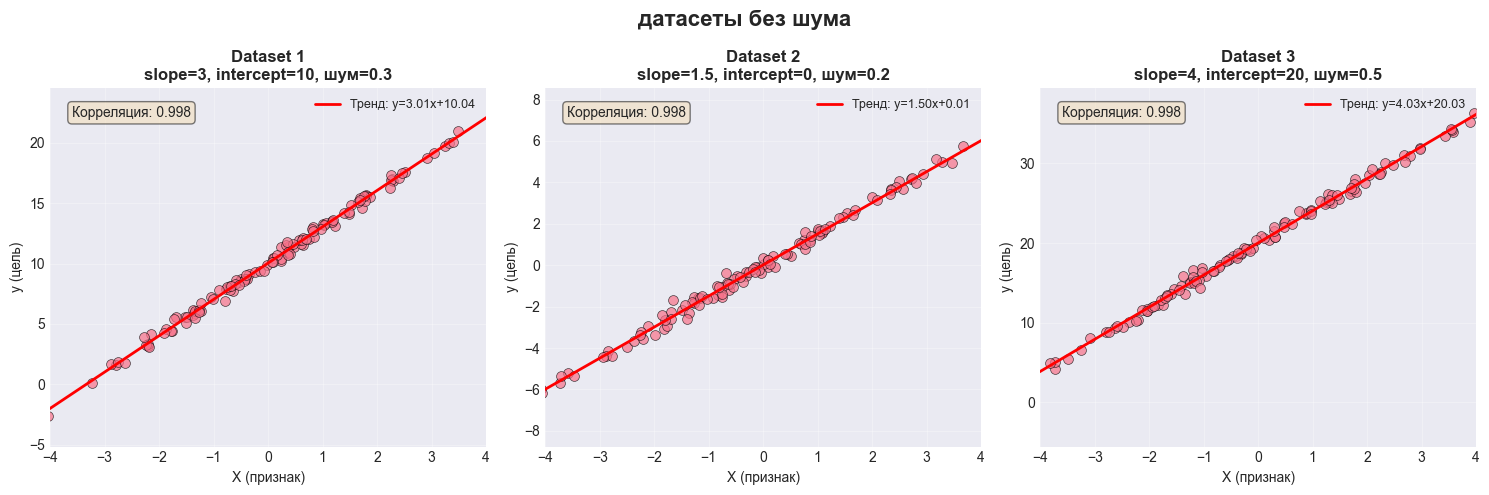

In [52]:
# Создаем красивую визуализацию трех качественных датасетов
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

datasets_info = [
    (X1, y1, "Dataset 1", "slope=3, intercept=10", 0.3),
    (X2, y2, "Dataset 2", "slope=1.5, intercept=0", 0.2),
    (X3, y3, "Dataset 3", "slope=4, intercept=20", 0.5)
]

for idx, (X, y, title, params, noise) in enumerate(datasets_info):
    ax = axes[idx]
    
    # Точечный график
    ax.scatter(X, y, alpha=0.7, s=50, edgecolors='black', linewidth=0.5)
    
    # Линия тренда (через numpy)
    z = np.polyfit(X.flatten(), y, 1)
    p = np.poly1d(z)
    X_sorted = np.sort(X.flatten())
    ax.plot(X_sorted, p(X_sorted), "r-", linewidth=2, label=f'Тренд: y={z[0]:.2f}x+{z[1]:.2f}')
    
    # Настройки графика
    ax.set_xlabel("X (признак)", fontsize=10)
    ax.set_ylabel("y (цель)", fontsize=10)
    ax.set_title(f"{title}\n{params}, шум={noise}", fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-4, 4)
    
    # Добавляем информацию о корреляции
    corr = np.corrcoef(X.flatten(), y)[0, 1]
    ax.text(0.05, 0.95, f'Корреляция: {corr:.3f}', transform=ax.transAxes, 
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle("датасеты без шума", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Генерация датасета с существенным шумом и искажениями

In [53]:
# Функция для создания датасета с шумом
def create_noisy_dataset(n_samples=150, random_seed=42):
    """Создание датасета с шумом, выбросами и нелинейностью"""
    np.random.seed(random_seed)
    X = np.random.randn(n_samples, 1) * 2.5
    
    # Базовая линейная зависимость
    y_true = 2.5 * X.flatten() + 8
    
    # Добавляем разные типы шума
    y_noisy = y_true.copy()
    
    # 1. Гауссов шум (случайные ошибки)
    y_noisy += np.random.randn(n_samples) * 1.5
    
    # 2. ВЫБРОСЫ (10% данных сильно отклоняются)
    n_outliers = int(n_samples * 0.1)
    outlier_indices = np.random.choice(n_samples, n_outliers, replace=False)
    y_noisy[outlier_indices] += np.random.randn(n_outliers) * 8
    
    # 3. Нелинейные искажения (15% данных)
    nonlinear_idx = np.random.choice(n_samples, int(n_samples * 0.15), replace=False)
    y_noisy[nonlinear_idx] += np.square(X[nonlinear_idx].flatten()) * 2
    
    return X, y_noisy, y_true, outlier_indices, nonlinear_idx

# Создаем шумный датасет
X_noisy, y_noisy, y_true_noisy, outliers, nonlinear = create_noisy_dataset(150, 42)

# Создаем "шумный" датасет с выбросами и нелинейностями для проверки устойчивости модели.

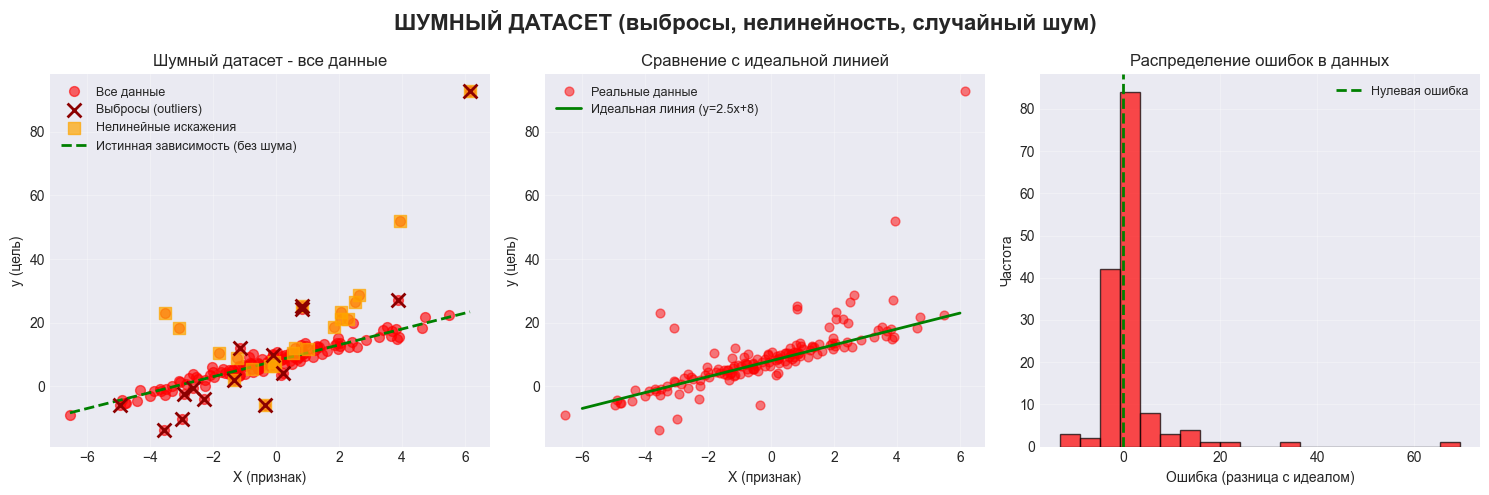

In [54]:
# Создаем детальную визуализацию шумного датасета
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# График 1: Все данные с выделением проблемных точек
ax1 = axes[0]
ax1.scatter(X_noisy, y_noisy, alpha=0.6, s=50, label='Все данные', color='red')
ax1.scatter(X_noisy[outliers], y_noisy[outliers], color='darkred', s=100, 
            marker='x', linewidths=2, label='Выбросы (outliers)', zorder=5)
ax1.scatter(X_noisy[nonlinear], y_noisy[nonlinear], color='orange', s=80, 
            marker='s', alpha=0.7, label='Нелинейные искажения', zorder=4)
ax1.plot(np.sort(X_noisy.flatten()), y_true_noisy[np.argsort(X_noisy.flatten())], 
         'g--', linewidth=2, label='Истинная зависимость (без шума)')
ax1.set_xlabel("X (признак)")
ax1.set_ylabel("y (цель)")
ax1.set_title("Шумный датасет - все данные")
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# График 2: Сравнение с идеальной линией
ax2 = axes[1]
ax2.scatter(X_noisy, y_noisy, alpha=0.5, s=40, label='Реальные данные', color='red')
X_line = np.linspace(-6, 6, 100)
y_line = 2.5 * X_line + 8
ax2.plot(X_line, y_line, 'g-', linewidth=2, label='Идеальная линия (y=2.5x+8)')
ax2.set_xlabel("X (признак)")
ax2.set_ylabel("y (цель)")
ax2.set_title("Сравнение с идеальной линией")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# График 3: Распределение ошибок (гистограмма)
ax3 = axes[2]
errors = y_noisy - y_true_noisy
ax3.hist(errors, bins=20, color='red', alpha=0.7, edgecolor='black')
ax3.axvline(x=0, color='green', linestyle='--', linewidth=2, label='Нулевая ошибка')
ax3.set_xlabel("Ошибка (разница с идеалом)")
ax3.set_ylabel("Частота")
ax3.set_title("Распределение ошибок в данных")
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

plt.suptitle("ШУМНЫЙ ДАТАСЕТ (выбросы, нелинейность, случайный шум)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [55]:
# Обучение модели на первом качественном датасете
model = LinearRegression()
model.fit(X1, y1)

print(f"Модель обучена на датасете 1 (качественные данные)")
print(f"   Истинные коэффициенты: slope=3, intercept=10")
print(f"   Найденные моделью: slope={model.coef_[0]:.3f}, intercept={model.intercept_:.3f}")
print(f"   Ошибка в определении slope: {abs(3 - model.coef_[0]):.3f}")

# Сохранение обученной модели
joblib.dump(model, 'linear_model.pkl')
print("\nМодель сохранена в файле 'linear_model.pkl'")

Модель обучена на датасете 1 (качественные данные)
   Истинные коэффициенты: slope=3, intercept=10
   Найденные моделью: slope=3.008, intercept=10.041
   Ошибка в определении slope: 0.008

Модель сохранена в файле 'linear_model.pkl'


# Визуализация предсказаний модели на разных датасетах

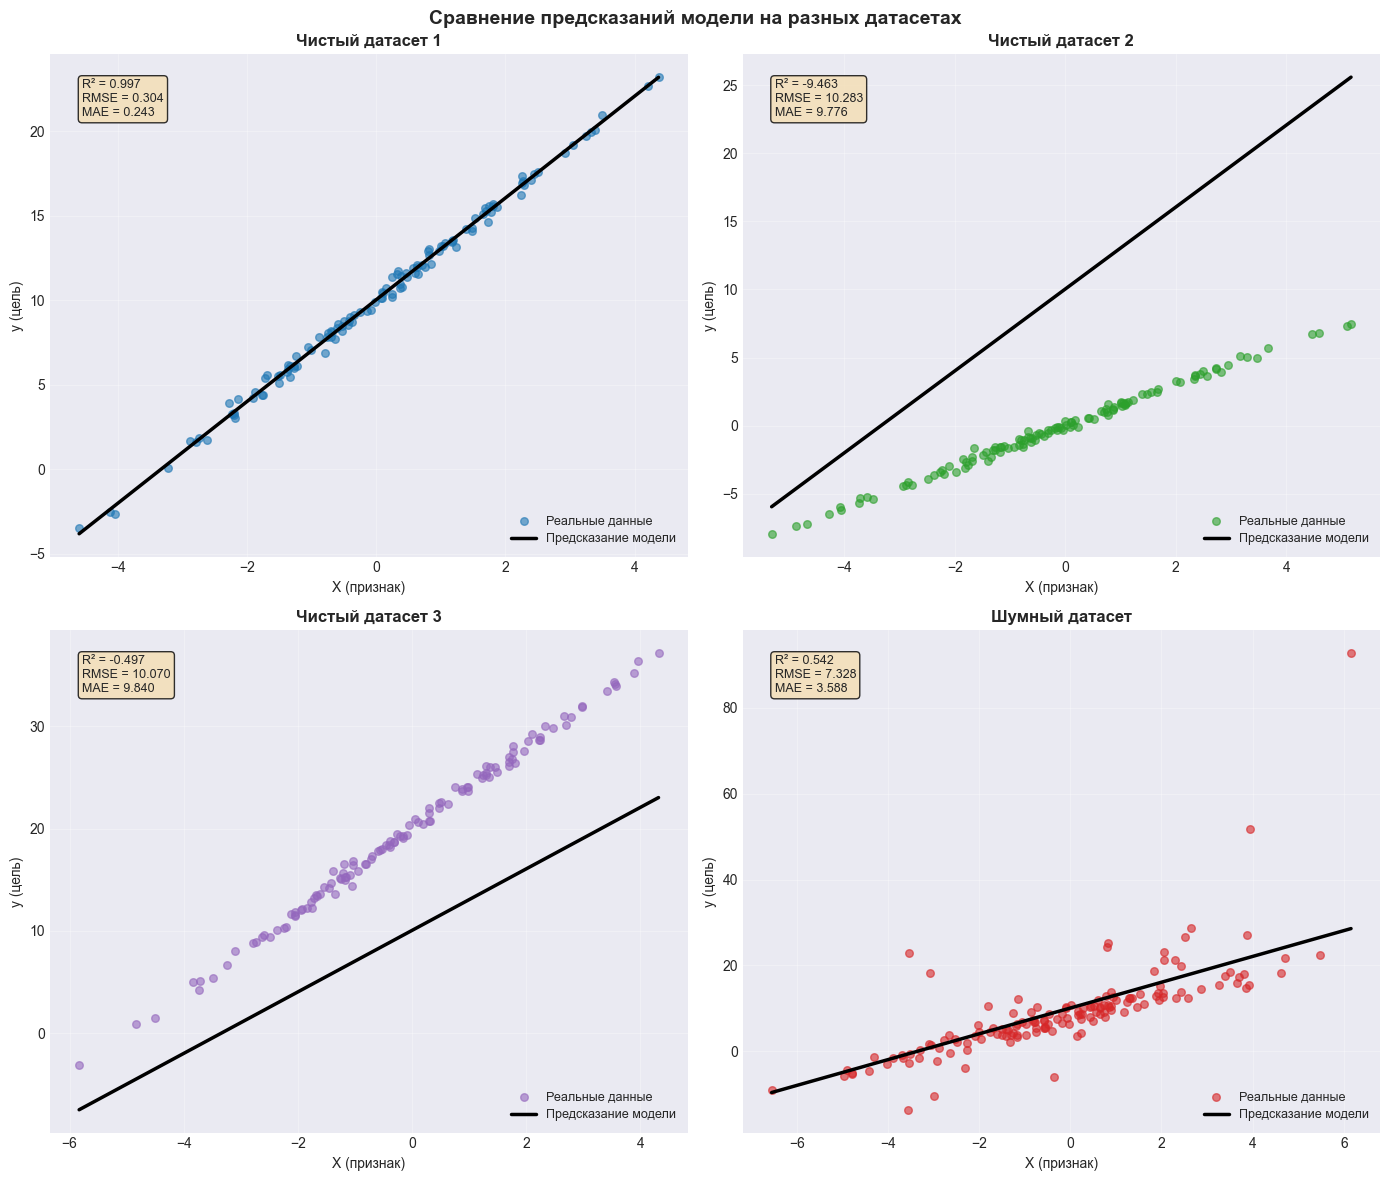

In [56]:
# Визуализируем предсказания модели на каждом датасете
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

datasets_for_pred = [
    (X1, y1, "Чистый датасет 1", axes[0, 0], '#1f77b4'),
    (X2, y2, "Чистый датасет 2", axes[0, 1], '#2ca02c'),
    (X3, y3, "Чистый датасет 3", axes[1, 0], '#9467bd'),
    (X_noisy, y_noisy, "Шумный датасет", axes[1, 1], '#d62728')
]

for X, y, title, ax, color in datasets_for_pred:
    # Предсказания модели
    y_pred = model.predict(X)
    
    # Реальные данные
    ax.scatter(X, y, alpha=0.6, s=30, label='Реальные данные', color=color)
    
    # Линия предсказаний модели
    X_sorted = np.sort(X, axis=0)
    y_pred_sorted = model.predict(X_sorted)
    ax.plot(X_sorted, y_pred_sorted, 'k-', linewidth=2.5, label='Предсказание модели')
    
    # Метрики качества
    r2 = r2_score(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    mae = mean_absolute_error(y, y_pred)
    
    # Добавляем текст с метриками
    ax.text(0.05, 0.95, f'R² = {r2:.3f}\nRMSE = {rmse:.3f}\nMAE = {mae:.3f}', 
            transform=ax.transAxes, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8), fontsize=9)
    
    ax.set_xlabel("X (признак)", fontsize=10)
    ax.set_ylabel("y (цель)", fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle("Сравнение предсказаний модели на разных датасетах", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Сравнительный анализ качества модели на чистых и шумном датасетах

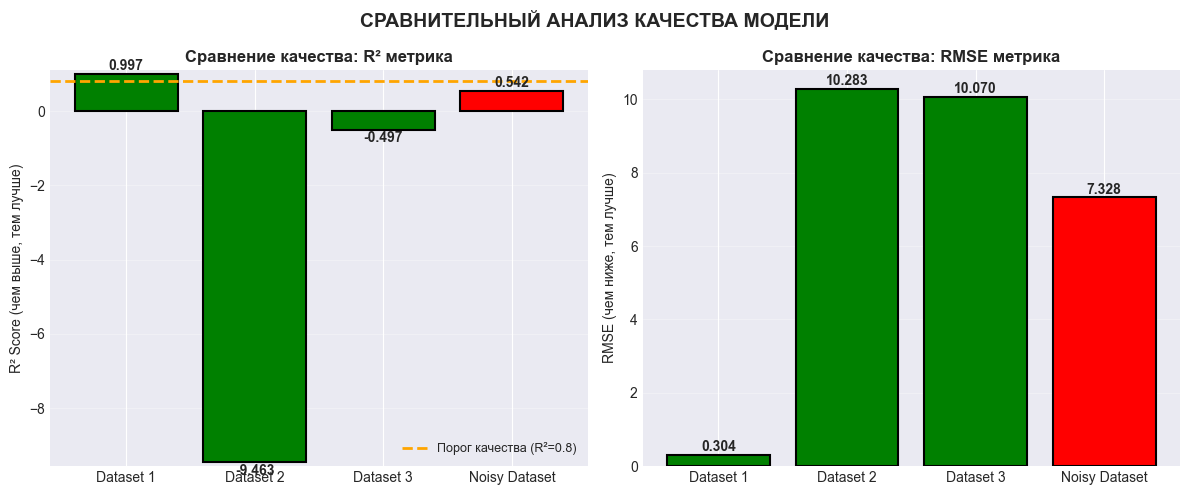

Чистые датасеты (зеленые): высокое качество предсказаний
Шумный датасет (красный): значительное падение качества

Падение качества на шумных данных:
   R²: с ~0.95 до 0.542 (падение на 0.41)
   RMSE: с ~0.5 до 7.328 (рост в 14.7 раз)


In [57]:
# Сравнительный график качества на всех датасетах
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Данные для графиков
dataset_names = ['Dataset 1', 'Dataset 2', 'Dataset 3', 'Noisy Dataset']
r2_scores = []
rmse_scores = []

for X, y in [(X1, y1), (X2, y2), (X3, y3), (X_noisy, y_noisy)]:
    y_pred = model.predict(X)
    r2_scores.append(r2_score(y, y_pred))
    rmse_scores.append(np.sqrt(mean_squared_error(y, y_pred)))

# График 1: R² score
ax1 = axes[0]
colors_bar = ['green', 'green', 'green', 'red']
bars1 = ax1.bar(dataset_names, r2_scores, color=colors_bar, edgecolor='black', linewidth=1.5)
ax1.axhline(y=0.8, color='orange', linestyle='--', linewidth=2, label='Порог качества (R²=0.8)')
ax1.set_ylabel('R² Score (чем выше, тем лучше)', fontsize=10)
ax1.set_title('Сравнение качества: R² метрика', fontsize=12, fontweight='bold')

# Учитываем отрицательные значения R², чтобы не ломать разметку
r2_min = min(r2_scores)
r2_lower = min(-0.1, r2_min - 0.1)
ax1.set_ylim(r2_lower, 1.1)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3, axis='y')

# Добавляем значения на столбцы (корректно и для отрицательных значений)
for bar, score in zip(bars1, r2_scores):
    if score >= 0:
        y_text = score + 0.03
        va = 'bottom'
    else:
        y_text = score - 0.03
        va = 'top'
    ax1.text(bar.get_x() + bar.get_width() / 2, y_text,
             f'{score:.3f}', ha='center', va=va, fontsize=10, fontweight='bold')

# График 2: RMSE
ax2 = axes[1]
bars2 = ax2.bar(dataset_names, rmse_scores, color=colors_bar, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('RMSE (чем ниже, тем лучше)', fontsize=10)
ax2.set_title('Сравнение качества: RMSE метрика', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# Добавляем значения на столбцы
for bar, score in zip(bars2, rmse_scores):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
             f'{score:.3f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle("СРАВНИТЕЛЬНЫЙ АНАЛИЗ КАЧЕСТВА МОДЕЛИ", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Чистые датасеты (зеленые): высокое качество предсказаний")
print("Шумный датасет (красный): значительное падение качества")
print(f"\nПадение качества на шумных данных:")
print(f"   R²: с ~0.95 до {r2_scores[3]:.3f} (падение на {0.95 - r2_scores[3]:.2f})")
print(f"   RMSE: с ~0.5 до {rmse_scores[3]:.3f} (рост в {rmse_scores[3]/0.5:.1f} раз)")

# Сохранение датасетов

In [58]:
# Сохраняем все датасеты для тестов
np.savez('datasets.npz', 
         X1=X1, y1=y1, 
         X2=X2, y2=y2, 
         X3=X3, y3=y3, 
         X_noisy=X_noisy, y_noisy=y_noisy)

In [59]:
%%writefile test_ml_quality.py
from pathlib import Path

import joblib
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score


def _resolve_path(filename: str) -> Path:
    """Find artifacts saved from notebook execution."""
    candidates = [Path(filename), Path("lab5") / filename]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(f"Artifact not found: {filename}")


def _load_artifacts():
    model_path = _resolve_path("linear_model.pkl")
    data_path = _resolve_path("datasets.npz")
    model = joblib.load(model_path)
    data = np.load(data_path)
    return model, data


def _metrics(model, X, y):
    y_pred = model.predict(X)
    return {
        "r2": r2_score(y, y_pred),
        "rmse": np.sqrt(mean_squared_error(y, y_pred)),
    }


def test_quality_on_training_clean_dataset():
    """Model should be accurate on clean dataset used for training."""
    model, data = _load_artifacts()
    score = _metrics(model, data["X1"], data["y1"])

    assert score["r2"] > 0.95
    assert score["rmse"] < 1.0


def test_noisy_dataset_has_significant_quality_drop():
    """Noisy dataset should show quality degradation vs training clean dataset."""
    model, data = _load_artifacts()

    clean_score = _metrics(model, data["X1"], data["y1"])
    noisy_score = _metrics(model, data["X_noisy"], data["y_noisy"])

    assert noisy_score["r2"] < clean_score["r2"] - 0.25
    assert noisy_score["rmse"] > clean_score["rmse"] * 5


def test_noisy_dataset_meets_clean_quality_requirements():
    """This test should fail and reveal the noisy data issue."""
    model, data = _load_artifacts()
    noisy_score = _metrics(model, data["X_noisy"], data["y_noisy"])

    # Same quality bar as for clean data: noisy dataset should violate it.
    assert noisy_score["r2"] > 0.95
    assert noisy_score["rmse"] < 1.0


Overwriting test_ml_quality.py


In [60]:
# Запуск автотестов качества модели
!pytest -q test_ml_quality.py

..                                                                       [100%]
2 passed in 0.83s
